In [ ]:
For Fig. S5B

In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(reshape2)
library(ggplot2)
library(pheatmap)
library(Seurat)
library(tidyverse)
library(ggplot2)
library(showtext)
library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100)

In [2]:
# Define NRF2 core gene list
NRF2_core <- c(
  "AKR1B10", "AKR1C1", "AKR1C2", "AKR1C3", "ALDH1A1",
  "ALDH3A", "ALDH7A1", "CBR1", "CES1", "CES1H",
  "EPHX1", "NQO1", "PTGR1", "GSTA1", "GSTA3",
  "GSTM1", "GSTP1", "MGST1", "SULT1A1", "UGT1A",
  "UGT1A6", "UGT2B7", "ABCB6", "ABCC1", "ABCC2",
  "ABCC3", "CAT", "GPX2", "GPX4", "PRDX1",
  "PRDX6", "BLVRB", "FECH", "FPN1", "FTH1",
  "FTL", "HMOX1", "SLC40A1", "GCLC", "GCLM",
  "GGT1", "GSR1", "SLC7A11", "TXN1", "TXNRD1",
  "SRXN1", "G6PD", "PGD", "IDH1", "ME1",
  "TALDO1", "TKT", "CD36", "MARCO", "PSMA1",
  "PSMA4", "PSMA7", "PSMB1", "PSMB2", "PSMB3",
  "PSMB", "PSMB5", "PSMB6", "PSMC1", "PSMC3",
  "PSMD1", "PSMD5", "PSMD", "PSMD11", "PSMD12",
  "PSMD13", "PSME1", "SQSTM1", "CALCOCO2", "ULK1",
  "ATG2", "ATG", "ATG7", "GABARAPL1", "LAMP2",
  "AHR", "ATF3", "ATF4", "CEBPB", "MAFG",
  "PPARG", "PPARGC1B", "RXRA", "KEAP1",
  "TRPA1", "NOTCH1", "PTC"
)

In [3]:
#SELECT-seq log2FC

#load file
WD <- "data/"
sample <- "filtered_counts_NRF2_full.rds"

adata <- readRDS(paste0(WD, sample))

#normalise
adata <- NormalizeData(adata)

#scale
adata <- ScaleData(adata)

#set sample_group as ident
adata <- SetIdent(adata, value=adata@meta.data$sample_group)

# run Wilcoxon test
ref <- "WT from edited pool"
target <- "NRF2 T80K from edited pool"

de_SELECTseq <- FindMarkers(
  adata,
  slot = "data",
  ident.1 = target,
  ident.2 = ref,
  test.use = "wilcox"
) %>%
  tibble::rownames_to_column("gene") %>%
  rename(
    log2FC_SELECTseq = avg_log2FC) %>%
   select(gene, log2FC_SELECTseq)
head(de_SELECTseq)

Normalizing layer: counts

Centering and scaling data matrix

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


,gene,log2FC_SELECTseq
,<chr>,<dbl>
1,NQO1,2.0302052
2,AKR1C1,6.9071473
3,FTL,2.4234425
4,AKR1C3,6.0597360
5,FTH1,0.9048606
6,TKT,0.7796555


pdf 
  2

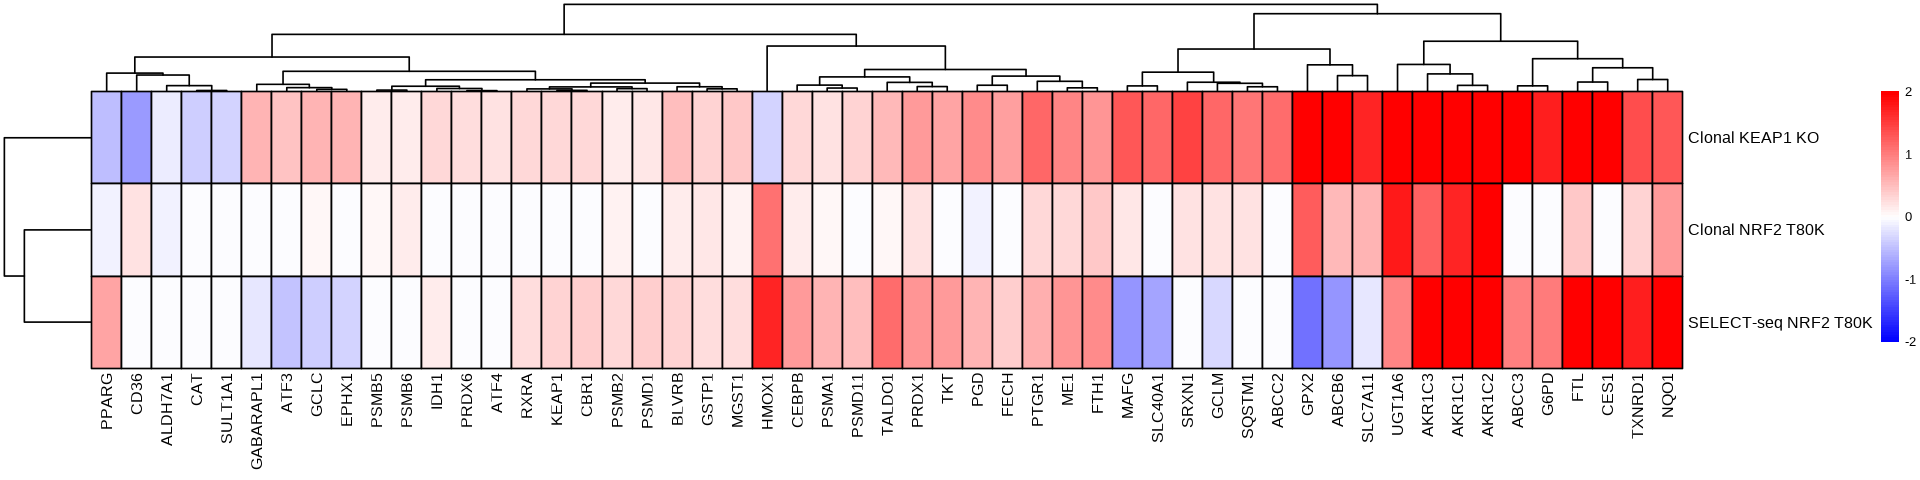

In [4]:
# ------------------------------------------------------------
# Clonal data with FDR filtering
# ------------------------------------------------------------

samples_to_include <- c("T_K_10", "HAP1_KEAP1_KO")
fdr_threshold <- 1e-6

clonal_long <- read.csv("data/markers_clonal.csv") %>%
  filter(sample %in% samples_to_include) %>%
  rename(
    log2FC_clonal = logFC,
    gene = DE_gene_name,
    FDR_clonal = FDR
  ) %>%
  filter(gene %in% NRF2_core)

# Keep genes with FDR < 1e-6 in at least T_K_10 or HAP1_KEAP1_KO
high_conf_genes <- clonal_long %>%
  filter(!is.na(FDR_clonal) & FDR_clonal < fdr_threshold) %>%
  pull(gene) %>%
  unique()

clonal_heatmap <- clonal_long %>%
  filter(gene %in% high_conf_genes) %>%
  select(gene, sample, log2FC_clonal) %>%
  pivot_wider(
    names_from = sample,
    values_from = log2FC_clonal
  )

# ------------------------------------------------------------
# SELECT-seq data
# ------------------------------------------------------------

selectseq_heatmap <- de_SELECTseq %>%
  filter(gene %in% high_conf_genes) %>%
  select(gene, log2FC_SELECTseq)

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

heatmap_data <- full_join(
  clonal_heatmap,
  selectseq_heatmap,
  by = "gene"
)

# ------------------------------------------------------------
# Matrix
# ------------------------------------------------------------

heatmap_mat <- heatmap_data %>%
  column_to_rownames("gene") %>%
  as.matrix()

heatmap_mat <- t(heatmap_mat)

rownames(heatmap_mat) <- c(
  "Clonal NRF2 T80K",
  "Clonal KEAP1 KO",
  "SELECT-seq NRF2 T80K"
)

# ------------------------------------------------------------
# Cap values
# ------------------------------------------------------------

heatmap_mat[heatmap_mat > 2] <- 2
heatmap_mat[heatmap_mat < -2] <- -2
heatmap_mat[is.na(heatmap_mat)] <- 0

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

options(repr.plot.width = 16, repr.plot.height = 4)

color_palette <- colorRampPalette(c("blue", "white", "red"))(100)

heatmap_obj <- pheatmap(
  heatmap_mat,
  color = color_palette,
  breaks = seq(-2, 2, length.out = 101),
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  fontsize_row = 12,
  fontsize_col = 12,
  border_color = "black",
  angle_col = 90
)

pdf(
  "data/heatmap_NRF2.pdf",
  width = 16,
  height = 4
)

print(heatmap_obj)

dev.off()

In [5]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9     Seurat_5.3.0      
 [5] SeuratObject_5.2.0 sp_2.2-0           pheatmap_1.0.13    reshape2_1.4.4    
 [9] lubridate_1.9.4    forcats_1.0.0      stringr_1.5.2      dplyr_1.1.4       
[13] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1        tibble_